<a href="https://colab.research.google.com/github/YashhCanCode/Price_Prediction/blob/main/price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
print(df.shape)
print(df.head)

(1460, 81)
<bound method NDFrame.head of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandC

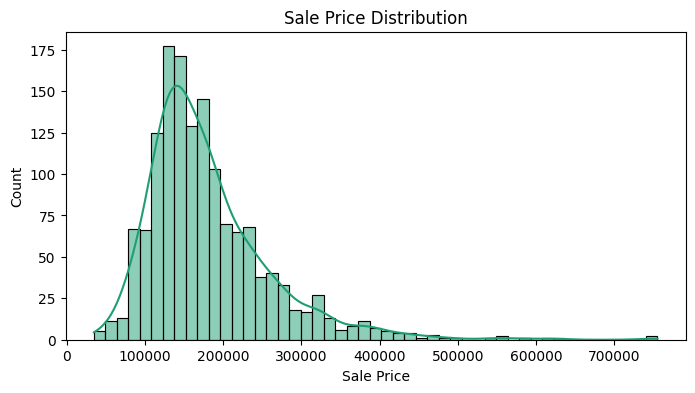

Average price: $180,921
Min price: $34,900
Max price: $755,000


In [2]:
# Target variable distribution
plt.figure(figsize=(8,4))
sns.histplot(df['SalePrice'], kde=True, color='#1D9E75')
plt.title('Sale Price Distribution')
plt.xlabel('Sale Price')
plt.show()

print(f"Average price: ${df['SalePrice'].mean():,.0f}")
print(f"Min price: ${df['SalePrice'].min():,.0f}")
print(f"Max price: ${df['SalePrice'].max():,.0f}")

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [4]:
# Columns where NaN means "None/doesn't exist"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

# Numerical columns where NaN means 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'MasVnrArea']

for col in zero_cols:
    df[col] = df[col].fillna(0)

# LotFrontage — fill with median per neighbourhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical — fill with most common value
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Verify no missing values remain
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [5]:
# Total square footage — more useful than individual area columns
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# House age at time of sale
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Was the house remodelled?
df['Remodelled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# Total bathrooms
df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 +
                   df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)

# Quick check
print(df[['TotalSF', 'HouseAge', 'Remodelled', 'TotalBath', 'SalePrice']].head())

   TotalSF  HouseAge  Remodelled  TotalBath  SalePrice
0     2566         5           0        3.5     208500
1     2524        31           0        2.5     181500
2     2706         7           1        3.5     223500
3     2473        91           1        2.0     140000
4     3343         8           0        3.5     250000


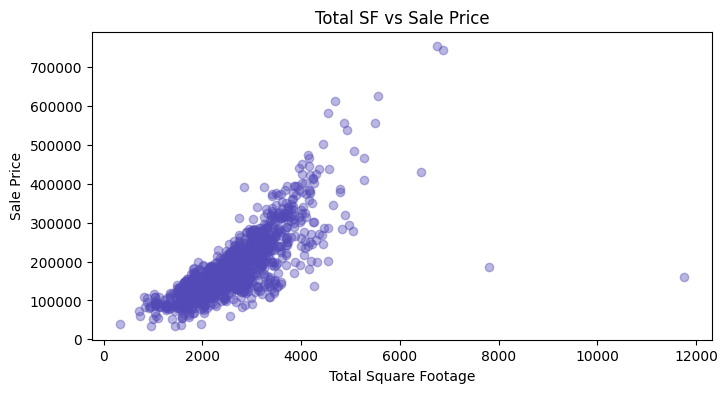

Correlation between TotalSF and SalePrice: 0.7823


In [6]:
plt.figure(figsize=(8,4))
plt.scatter(df['TotalSF'], df['SalePrice'], alpha=0.4, color='#534AB7')
plt.xlabel('Total Square Footage')
plt.ylabel('Sale Price')
plt.title('Total SF vs Sale Price')
plt.show()

print(f"Correlation between TotalSF and SalePrice: {df['TotalSF'].corr(df['SalePrice']):.4f}")

In [7]:
# Drop columns that aren't useful for prediction
df = df.drop(['Id', 'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold'], axis=1)

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# One-hot encode categorical columns
X = pd.get_dummies(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 302)
Target shape: (1460,)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (1168, 302)
Test set: (292, 302)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Model 1 — Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Model 2 — Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

# Model 3 — Gradient Boost
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                max_depth=3, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_preds = gb.predict(X_test_scaled)

print("All three models trained successfully")

All three models trained successfully


In [10]:
models = {
    'Linear Regression': lr_preds,
    'Random Forest': rf_preds,
    'Gradient Boost': gb_preds
}

print(f"{'Model':<25} {'R²':>8} {'RMSE':>12}")
print("-" * 47)

for name, preds in models.items():
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name:<25} {r2:>8.4f} {rmse:>12,.0f}")

Model                           R²         RMSE
-----------------------------------------------
Linear Regression           0.4565       64,566
Random Forest               0.8845       29,767
Gradient Boost              0.9119       25,991


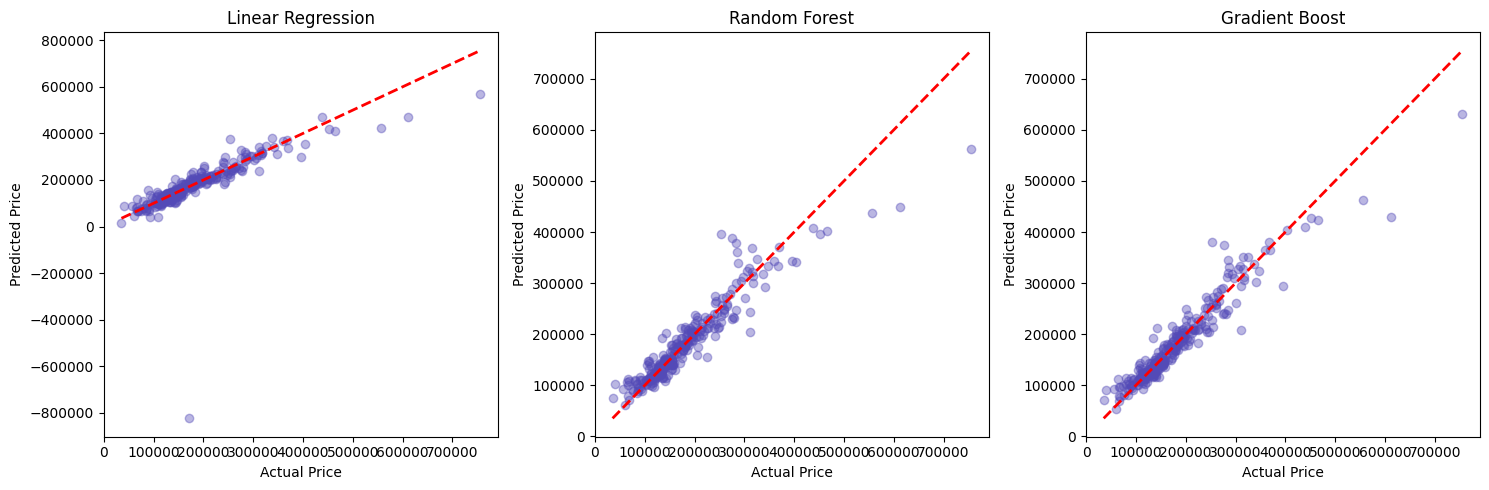

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, preds) in zip(axes, models.items()):
    ax.scatter(y_test, preds, alpha=0.4, color='#534AB7')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)

plt.tight_layout()
plt.show()

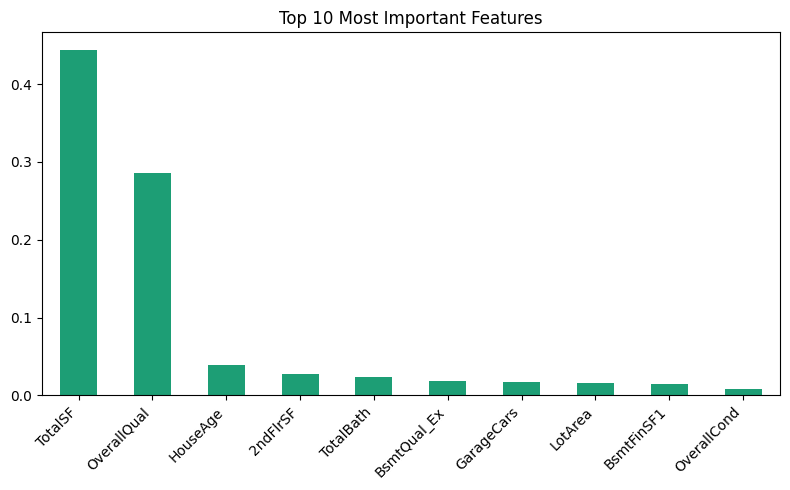

TotalSF        0.444422
OverallQual    0.285274
HouseAge       0.039287
2ndFlrSF       0.027105
TotalBath      0.023551
BsmtQual_Ex    0.018320
GarageCars     0.017607
LotArea        0.015676
BsmtFinSF1     0.014939
OverallCond    0.008510
dtype: float64


In [12]:
importances = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='#1D9E75')
plt.title('Top 10 Most Important Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(importances)

In [13]:
def predict_house(total_sf, overall_qual, house_age, total_bath):
    # Create a sample with all zeros
    sample = pd.DataFrame(0, index=[0], columns=X.columns)

    # Fill in our known features
    sample['TotalSF'] = total_sf
    sample['OverallQual'] = overall_qual
    sample['HouseAge'] = house_age
    sample['TotalBath'] = total_bath

    # Scale and predict
    sample_scaled = scaler.transform(sample)
    pred = gb.predict(sample_scaled)[0]
    print(f"Predicted Sale Price: ${pred:,.0f}")

# Test it
print("Large new house, excellent quality:")
predict_house(total_sf=3000, overall_qual=9, house_age=2, total_bath=3)

print("Small old house, average quality:")
predict_house(total_sf=1200, overall_qual=5, house_age=40, total_bath=1)

print("Medium house, good quality:")
predict_house(total_sf=2000, overall_qual=7, house_age=15, total_bath=2)

Large new house, excellent quality:
Predicted Sale Price: $191,811
Small old house, average quality:
Predicted Sale Price: $55,731
Medium house, good quality:
Predicted Sale Price: $108,988
